To Understand The Syntax To langhgraph using simple workflow


In [15]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [16]:
#define State
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [17]:
#Node 1 calculate Bmi
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state["weight_kg"]
    height = state["height_m"]

    bmi = weight / (height ** 2)

    state["bmi"] = round(bmi, 2)
    return state

In [18]:
#Node 2 According to Bmi categorize the person 
def category(state=BMIState)->BMIState:
    bmi=state["bmi"]
    
    # Classify based on the standard ranges
    if bmi < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi <= 24.9:
        category = "Healthy / Normal Weight"
    elif 25.0 <= bmi <= 29.9:
        category = "Overweight"
    elif 30.0 <= bmi <= 34.9:
        category = "Class 1 Obesity (Moderate)"
    elif 35.0 <= bmi <= 39.9:
        category = "Class 2 Obesity (Severe)"
    else:
        category = "Class 3 Obesity (Morbid/Severe)"
        
    state["category"]=category
    return state

In [ ]:
#define graph
graph=StateGraph(BMIState)

#add nodes 
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("category",category)

#add edges
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi","category")
graph.add_edge("category",END)

#compile
Workflow=graph.compile()





In [24]:
#execute
initial_state={
    "weight_kg": 80,
    "height_m": 1.73
}
final_state=Workflow.invoke(initial_state)

In [25]:
final_state

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}

In [26]:
#visualize the workflow

from IPython.display import Image, display



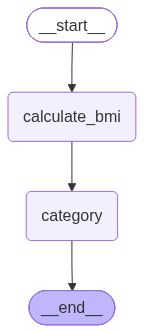

In [23]:
# 4. Draw and display the graph
display(Image(Workflow.get_graph().draw_mermaid_png()))
